# load data
<h1 style="color:#1f4e79;">1. WHAT IS A SEQUENTIAL DATASET</h1>

<h2 style="color:#2f75b5;">1.1 Sequential data</h2>

<h3 style="color:#5b9bd5;">A timestep is not necessarily the correct unit</h3>

In [5]:
# LOAD DAAT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_train = np.load(
    "/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/X_part2.npy"
)

X_val = np.load(
    "/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/X_val_part2.npy"
)

y_val = np.load(
    "/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/y_val_part2.npy"
)

In [6]:
X_val.shape, y_val.shape

((100, 11), (100,))

In [41]:
# setup
import numpy as np

### Table of contents

[1. Overview](#1) <br>
[2. Anális de Datos](#2) <br>
[3. Setup](#3) <br>
[4. Loading data](#4) <br>
[5. Data Quality](#5) <br>
[6. Feature distributions](#6) <br>
[7. Feature scale comparisson](#7) <br>
[8. Correlation analysis](#8) <br>
[9. Temporal structure](#9) <br>
[10. Validation Anomaly Distributions](#10) <br>
    &emsp;&emsp; [10.1. Where are the anomalies?](#10.1) <br>
    &emsp;&emsp; [10.2. Compare normal vs anomalous distributions](#10.2) <br>
    &emsp;&emsp; [10.3. Anomalies over the feature space](#10.3) <br>
[11. Summary](#2) <br>


## Tabla de Contenidos
[1. Introducción](#introduccion) <br>
[2. Anális de Datos](#analisis-datos)
[3. Conclusiones](#conclusiones)




[3. Conclusiones](#9)





[3. PRep...](#11)

<a id="introduccion"></a>
## 1. Introducción
Aquí va el contenido de la introducción...

<h1 align="center">
  <span style="color: #440E03;">Centered, Bold Title</span>
</h1>

<h2 align="left">
  <span style="color: #9C2007;">Centered, Bold Title</span>
</h2>





<h2 align="left]">
  <span style="color: #C82909;">Centered, Bold Title</span>
</h2>

# Table of Contents

1. [What is a Sequential Dataset](#1-sequential-data)
2. [Why Introduce Windowing](#2-why-introduce-windowing)
3. [The Windowing Transformation](#3-the-windowing-transformation)
4. [Applying Windowing to the Dataset](#4-applying-windowing-to-the-dataset)
5. [Distribution Before and After Windowing](#5-distribution-before-and-after-windowing)
6. [Window Size as a Modeling Decision](#6)
7. [Stride and Overlap](#7-stride-and-overlap)
8. [Label Mapping for Windowed Data](#8-label-mapping-for-windowed-data)
9. [Model Representations](#9-model-representations)
10. [Preprocessing, Splitting and Evaluation](#10-preprocessing-splitting-and-evaluation)
11. [Decision Framework](#11-decision-framework)
12. [Final Recap](#12-final-recap)

In [ ]:
# https://chatgpt.com/c/6aa98879-b8d8-83e9-b524-2c3785a63463

# <b> <center> <font color="#126430"> 1. Windowing for Sequential Machine Learning </font> </center> </b>

## <b> <font color="#188B42"> 1.2. Purpose </font></b>

Windowing is a fundamental transformation used when applying machine learning
to sequential or time-dependent data.

Rather than treating each timestep as an independent observation, windowing
groups consecutive observations into fixed-length temporal segments:

$$
W_i = [x_i, x_{i+1}, \ldots, x_{i+w-1}]
$$

where:

- \(w\) is the window size
- \(i\) is the starting position of the window

Consecutive windows may overlap depending on the stride.

This notebook studies windowing as a **modeling decision**, rather than merely
as a preprocessing operation.

The goal is to understand:

- why windows are introduced;
- how window size and stride affect the resulting dataset;
- how windowing changes the representation of the data;
- how overlapping windows affect observations and their dependence;
- how point-level labels can be mapped to window-level labels;
- how windowed data can be represented for sequential and non-sequential models;
- how windowing interacts with preprocessing and evaluation;
- and how to reason about these decisions in future sequential ML projects.

The examples use a server-monitoring anomaly-detection dataset as a running
example, but the concepts and methodology are intended to be applicable to
other sequential ML problems.

<center>
Sequential data → Why window? → What does windowing change? → How do size/stride affect those changes? → How do labels map to windows? → How do models consume windows? → What decisions/trade-offs must be made?
    </center>

# <b> <center> <font color="#126430"> 2. What is a sequential dataset </font> </center> </b>

## <b> <font color="#188B42"> 2.1. Sequential data </font></b>

A sequential dataset consists of observations ordered according to some
meaningful progression, commonly time.

We can represent a multivariate sequence as:

$$
X \in \mathbb{R}^{T \times F}
$$

where:

- $T$ = number of observations or timesteps
- $F$ = number of features
- $x_t \in \mathbb{R}^{F}$ = feature vector at timestep $t$

For example, in a server-monitoring problem, each timestep may contain
measurements such as CPU usage, memory usage, network activity, or other
system metrics.

The important property is not simply that the observations have timestamps.
It is that their **ordering may contain information relevant to the task**.

For example:

$$
x_t \rightarrow x_{t+1} \rightarrow x_{t+2}
$$

may contain a temporal pattern that cannot be represented adequately by
considering each observation independently.


---

### <b> <font color="#1FB255"> 2.1.1. A timestep is not necessarily the correct unit of analysis </font></b>



Before introducing windowing, we should ask:

> **What should one training observation represent?**

A timestep-based representation assumes:

$$
\text{one observation} = x_t
$$

A window-based representation instead assumes:

$$
\text{one observation} = W_i
$$

This is a modeling decision.

Windowing therefore changes not only the shape of the data, but also the
**unit of analysis** used by the model.

# <b> <center> <font color="darkgreen"> 3. Why introduce windowing </font> </center> </b>

If the ordering of observations contains useful information, treating every
timestep as an independent observation may be insufficient.

Consider the following sequence:

$$
x_1, x_2, x_3, \ldots, x_T
$$

A point-wise representation gives the model access to one timestep at a time:

$$
x_t
$$

However, many sequential phenomena are characterized not by an individual
observation, but by a **pattern across multiple consecutive observations**.

For example, the following sequences may have the same value at their final
timestep:

$$
[10, 10, 10, 11]
$$

and

$$
[5, 7, 9, 11]
$$

A point-wise model observing only the value $11$ cannot distinguish these
temporal contexts.

A model that receives a sequence of observations can potentially learn that
the two situations represent different temporal behaviors.

Windowing provides a way to represent this local temporal context.

Instead of presenting:

$$
x_t
$$

as one observation, we construct a window:

$$
W_t = [x_t, x_{t+1}, \ldots, x_{t+w-1}]
$$

where $w$ is the **window size**.

The dataset therefore changes from:

$$
X \in \mathbb{R}^{T \times F}
$$

to:

$$
X_W \in \mathbb{R}^{N_W \times W \times F}
$$

where:

- $N_W$ = number of windows
- $W$ = number of timesteps in each window
- $F$ = number of features

The important idea is that **a window becomes the new unit of analysis.**

---

### Windowing is a modeling decision

Windowing should not be introduced simply because the data is sequential.

The decision should be based on the temporal structure of the phenomenon and
the requirements of the task.

For example:

- A very short window may fail to capture a meaningful temporal pattern.
- A very long window may include unrelated behaviors.
- A window that is appropriate for detecting short-lived events may be
  inappropriate for detecting long-term trends.
- The appropriate window size may depend on the sampling frequency of the data.

Therefore, the question is not simply:

> "What window size should I use?"

A better question is:

> **"What temporal context should one model observation represent?"**

The rest of this notebook explores the consequences of answering that
question in different ways.

# <b> <center> <font color="#126430"> 4. The windowing transformation</font> </center> </b>


A window is created by selecting a consecutive segment of the original
sequence.

Two parameters determine how this is done:

- **Window size ($W$)**: number of consecutive timesteps contained in each
  window.
- **Stride ($S$)**: number of timesteps by which the window moves before the
  next window is created.

For a sequence:

$$
x_0, x_1, x_2, \ldots, x_{T-1}
$$

a window starting at position $i$ is:

$$
W_i =
[x_i, x_{i+1}, \ldots, x_{i+W-1}]
$$

The starting positions are determined by the stride:

$$
0,\ S,\ 2S,\ 3S,\ldots
$$

until a complete window can no longer be formed.

---

### Example

Consider a simple sequence containing ten observations:

$$
X = [0,1,2,3,4,5,6,7,8,9]
$$

and choose:

$$
W = 5,\qquad S = 1
$$

The resulting windows are:

$$
W_0 = [0,1,2,3,4]
$$

$$
W_1 = [1,2,3,4,5]
$$

$$
W_2 = [2,3,4,5,6]
$$

and so on.

Notice that consecutive windows share observations.

This is called **overlapping windowing**.

---

### Non-overlapping windows

If instead:

$$
W = 5,\qquad S = 5
$$

the windows become:

$$
W_0 = [0,1,2,3,4]
$$

$$
W_1 = [5,6,7,8,9]
$$

There is no overlap between consecutive windows.

Therefore, window size and stride determine not only the amount of temporal
context available to the model, but also how much of the original sequence is
shared between observations in the windowed dataset.

In [42]:
def create_windows(X, window_size, stride):
    windows = []

    for start in range(0, len(X) - window_size + 1, stride):
        windows.append(X[start:start + window_size])

    return np.asarray(windows)


X_toy = np.arange(10)

W = 5
S = 1

X_windows = create_windows(
    X_toy,
    window_size=W,
    stride=S,
)

print(X_windows)
print("Shape:", X_windows.shape)

[[0 1 2 3 4]
 [1 2 3 4 5]
 [2 3 4 5 6]
 [3 4 5 6 7]
 [4 5 6 7 8]
 [5 6 7 8 9]]
Shape: (6, 5)


### Number of windows

For a sequence of length $T$, window size $W$, and stride $S$, the number of
complete windows is:

$$
N_W =
\left\lfloor
\frac{T-W}{S}
\right\rfloor + 1
$$

For the example above:

$$
T = 10,\qquad W = 5,\qquad S = 1
$$

therefore:

$$
N_W =
\left\lfloor
\frac{10-5}{1}
\right\rfloor + 1
= 6
$$

The number of windows is therefore not equal to the number of original
timesteps.

This is our first important consequence of windowing:

> **Windowing changes the number and structure of observations in the
> dataset.**

In [43]:
for stride in [1, 2, 5]:
    windows = create_windows(
        X_toy,
        window_size=5,
        stride=stride,
    )

    print(f"stride={stride}")
    print(windows)
    print(f"shape={windows.shape}")
    print()

stride=1
[[0 1 2 3 4]
 [1 2 3 4 5]
 [2 3 4 5 6]
 [3 4 5 6 7]
 [4 5 6 7 8]
 [5 6 7 8 9]]
shape=(6, 5)

stride=2
[[0 1 2 3 4]
 [2 3 4 5 6]
 [4 5 6 7 8]]
shape=(3, 5)

stride=5
[[0 1 2 3 4]
 [5 6 7 8 9]]
shape=(2, 5)



### What has changed?

The original dataset contained:

$$
T
$$

individual observations.

After windowing, it contains:

$$
N_W
$$

window-level observations, where each observation contains $W$ timesteps.

The transformation therefore affects several properties simultaneously:

1. **Number of observations**
2. **Temporal context per observation**
3. **Overlap between observations**
4. **Dependence between observations**
5. **Representation consumed by the model**

These effects depend on both $W$ and $S$.

We will examine them separately before deciding what constitutes an
appropriate windowing strategy.

# <b> <center> <font color="#126430"> 5. Applying windowing to the dataset </font> </center> </b>

We now apply the windowing transformation to the running dataset.

The purpose of this section is exploratory: we want to understand how
different combinations of window size and stride transform the dataset before
making any modeling decision.

For the examples below, the original training data has the shape:

$$
X_{\text{train}} \in \mathbb{R}^{T \times F}
$$

with:

- $T = 1000$ timesteps
- $F = 11$ features

After windowing, the representation becomes:

$$
X_W \in \mathbb{R}^{N_W \times W \times F}
$$

where:
- The first dimension represents the number of windows, 
- The second represents the temporal dimension within each window, and
- The third represents the features.

We will first keep the window size fixed and vary the stride. Then we will
keep the stride fixed and vary the window size.

This allows us to isolate the effect of each parameter.

In [47]:
window_size = 5
stride = 1

X_train_w = create_windows(
    X_train,
    window_size=window_size,
    stride=stride,
)

print("Original shape:", X_train.shape)
print("Windowed shape:", X_train_w.shape)

Original shape: (1000, 11)
Windowed shape: (996, 5, 11)


### Interpreting the resulting shape

For:

$$
W = 5,\qquad S = 1
$$

the original representation:

$$
(1000, 11)
$$

becomes:

$$
(996, 5, 11)
$$

This means:

- 996 windows were created;
- each window contains 5 consecutive timesteps;
- each timestep contains 11 features.

Therefore, one model observation is now:

$$
5 \times 11
$$

rather than a single 11-dimensional timestep.

The number of windows is:

$$
N_W =
\left\lfloor
\frac{1000-5}{1}
\right\rfloor + 1
= 996
$$

Notice that the transformation has not created new measurements. It has
**reorganized existing measurements into temporal observations**.

In [48]:
# compare confs
configs = [
    (1, 1),
    (5, 1),
    (10, 1),
    (20, 1),
    (5, 5),
    (10, 10),
]

rows = []

for window_size, stride in configs:
    X_w = create_windows(
        X_train,
        window_size=window_size,
        stride=stride,
    )

    rows.append({
        "window_size": window_size,
        "stride": stride,
        "n_windows": X_w.shape[0],
        "window_shape": X_w.shape[1:],
    })

pd.DataFrame(rows)

,window_size,stride,n_windows,window_shape
0,1,1,1000,"(1, 11)"
1,5,1,996,"(5, 11)"
2,10,1,991,"(10, 11)"
3,20,1,981,"(20, 11)"
4,5,5,200,"(5, 11)"
5,10,10,100,"(10, 11)"


This table shows an important distinction.

Increasing the window size changes the amount of temporal context represented by
each observation.

Increasing the stride changes how densely those observations are sampled from
the original sequence.

These parameters therefore control different aspects of the transformation:

$$
\boxed{\text{Window size} \rightarrow \text{temporal context}}
$$

$$
\boxed{\text{Stride} \rightarrow \text{sampling density / overlap}}
$$

They should therefore be analyzed separately rather than treated as a single
"windowing parameter".

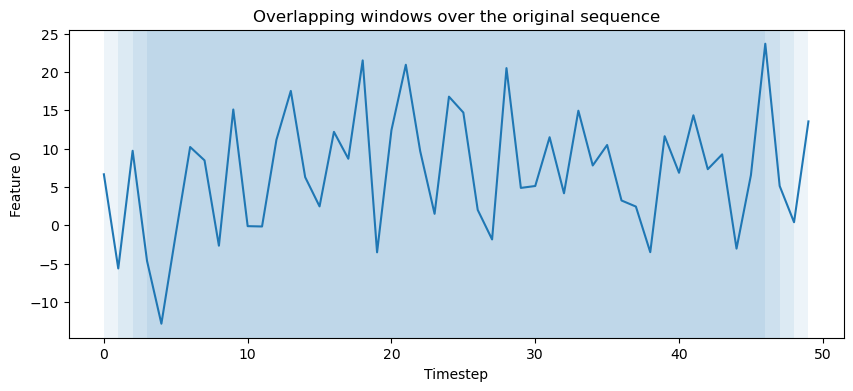

In [49]:
# simple visualization; see later
feature_idx = 0

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(X_train[:50, feature_idx], label="Original sequence")

window_size = 5
stride = 1

for start in range(0, 50 - window_size + 1, stride):
    ax.axvspan(
        start,
        start + window_size - 1,
        alpha=0.08,
    )

ax.set_xlabel("Timestep")
ax.set_ylabel(f"Feature {feature_idx}")
ax.set_title("Overlapping windows over the original sequence")
plt.show()

The shaded regions illustrate the windows moving across the original sequence.

With a stride of 1, consecutive windows differ by only one timestep.

For example:

$$
W_0 = [x_0,x_1,x_2,x_3,x_4]
$$

$$
W_1 = [x_1,x_2,x_3,x_4,x_5]
$$

Four out of five timesteps are shared between these two observations.

This means that overlapping windows are **not independent observations**.

The nominal number of windows can therefore be substantially larger than the
amount of independent information contained in the original sequence.



----------------------
Now we establish:

- what a window is;
- how W and S work;
- how the real dataset changes shape;
- how overlap appears;
- why windows aren't independent.

The natural next question is:

    If windowing changes the observations, does it also change the distribution of the data?

# <b> <center> <font color="#126430"> 6. Distribution before and after windowing </font> </center> </b>


Windowing reorganizes the original observations into temporal groups.

This raises an important question:

> Does windowing change the distribution of the data?

The answer depends on **which distribution we are examining**.

At least three different objects can be considered:

1. The distribution of individual feature values.
2. The distribution of statistics computed over windows.
3. The distribution of the model's actual input representation.

These should not be conflated.

We first establish the original feature-value distributions and then examine
how they are represented after windowing.

In [50]:
original_stats = pd.DataFrame({
    "mean": X_train.mean(axis=0),
    "std": X_train.std(axis=0),
    "min": X_train.min(axis=0),
    "max": X_train.max(axis=0),
})

original_stats.index = [
    f"feature_{i}" for i in range(X_train.shape[1])
]

original_stats

,mean,std,min,max
feature_0,4.939400,7.808642,-17.488978,28.384866
feature_1,-9.637268,7.294225,-38.593613,13.689702
feature_2,13.814707,7.649540,-9.913776,43.322411
feature_3,-10.464489,9.176276,-35.968341,16.082439
feature_4,-7.956229,8.078898,-35.351822,15.592370
feature_5,10.199504,9.464401,-19.691088,47.131732
feature_6,-6.019408,7.458787,-32.280955,25.473844
feature_7,7.969829,9.336077,-23.218312,41.978198
feature_8,-6.253182,5.443277,-22.039903,12.090256
feature_9,2.324513,8.413394,-23.459247,26.166271


This provides a reference for the feature distributions before windowing.

At this stage, each feature has one value per timestep.

For example, feature $j$ is represented by:

$$
X_{:,j}
=
[x_{1,j},x_{2,j},\ldots,x_{T,j}]
$$


After windowing, the same underlying values can appear in multiple windows,
depending on the stride.

Therefore, simply comparing summary statistics after flattening the windowed
dataset with the original statistics requires care.

Minimum coverage: 1
Maximum coverage: 5


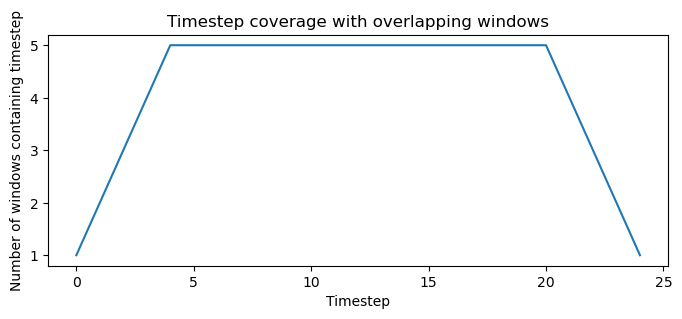

In [55]:
# what happens with overlapping widnows?
window_size = 5
stride = 1

def timestep_coverage(sequence_length, window_size, stride):
    coverage = np.zeros(sequence_length, dtype=int)

    for start in range(
        0,
        sequence_length - window_size + 1,
        stride,
    ):
        coverage[start:start + window_size] += 1

    return coverage

coverage = timestep_coverage(
    sequence_length=25, # len(X_train); 
    window_size=5,
    stride=1,
)

print("Minimum coverage:", coverage.min())
print("Maximum coverage:", coverage.max())

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(coverage)

ax.set_xlabel("Timestep")
ax.set_ylabel("Number of windows containing timestep")
ax.set_title("Timestep coverage with overlapping windows")

plt.show()



With window_size = 5 and stride = 1, the expected coverage is not a perfect rectangle. It should look like a plateau with short ramps at both boundaries.

For example, with a sequence of length 10:

Windows:

```
W0 = [0 1 2 3 4]
W1 =    [1 2 3 4 5]
W2 =       [2 3 4 5 6]
W3 =          [3 4 5 6 7]
W4 =             [4 5 6 7 8]
W5 =                [5 6 7 8 9]
```

Therefore, the number of windows covering each timestep is:

timestep:   0  1  2  3  4  5  6  7  8  9

coverage:   1  2  3  4  5  5  4  3  2  1


0 is covered by only 1 timestep, 1 is covered by 2...

### The more meaningful distribution: window-level properties

Instead of flattening windows and asking "what is the feature distribution?", ask:

"What is the distribution of the characteristics of my windows?"

For example, calculate the mean and standard deviation of each feature within each window.

--
We have now created a different type of distribution.

For each feature $j$, we can examine:

$$
\mu_{i,j}
=
\frac{1}{W}
\sum_{t=1}^{W} x_{i+t,j}
$$

This gives the distribution of **window-level means**.

Likewise, we can examine the distribution of within-window variability:

$$
\sigma_{i,j}
$$

These distributions describe properties of temporal segments rather than
individual observations.

This distinction is often more informative when evaluating whether a chosen
window size captures meaningful temporal structure.

Window means shape: (100, 11)
Window stds shape: (100, 11)


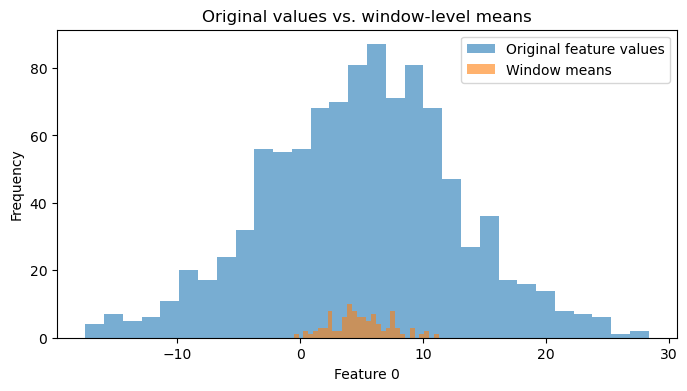

In [58]:
window_means = X_w.mean(axis=1)
window_stds = X_w.std(axis=1)

print("Window means shape:", window_means.shape)
print("Window stds shape:", window_stds.shape)

feature_idx = 0

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    X_train[:, feature_idx],
    bins=30,
    alpha=0.6,
    label="Original feature values",
)

ax.hist(
    window_means[:, feature_idx],
    bins=30,
    alpha=0.6,
    label="Window means",
)

ax.set_xlabel(f"Feature {feature_idx}")
ax.set_ylabel("Frequency")
ax.set_title("Original values vs. window-level means")
ax.legend()

plt.show()

The two histograms represent different quantities.

The first describes the distribution of individual observations.

The second describes the distribution of the average behavior of temporal
segments.

Therefore, after windowing, there is not necessarily one single "new
distribution."

Instead, windowing creates a new observational structure from which several
different distributions can be studied.

### Key takeaway

Windowing does more than change the shape of an array.

It changes the **unit of analysis** and, when windows overlap, changes how often
individual observations are represented in the resulting dataset.

Therefore, when analyzing the effect of windowing, we should distinguish
between:

- the original timestep-level distribution;
- the representation frequency introduced by overlap;
- distributions of window-level statistics;
- and the distribution of the actual model inputs.

The appropriate analysis depends on the question being asked.

In particular:

> **Windowing should be evaluated not only by its resulting tensor shape, but
> by how it changes the statistical and temporal structure presented to the
> model.**

# <b> <center> <font color="#126430"> 7. Window size as a modeling decision </font> </center> </b>


The window size determines how much temporal context is represented by a
single model input.

Given a sequence:

$$
x_0, x_1, \ldots, x_{T-1}
$$

a window of size $W$ represents:

$$
W_i = [x_i, x_{i+1}, \ldots, x_{i+W-1}]
$$

Therefore, choosing $W$ is not only a technical preprocessing choice. It is
also a **modeling assumption about the temporal scale of the problem**.

The key question is not simply:

> "What window size gives the best result?"

A better question is:

> **"Over what temporal scale is the pattern relevant to the task expected to occur?"**


---
## <b> <font color="#188B42"> 7.1. Small vs large windows </font></b>

Consider several possible window sizes:

$$
W \in \{1,5,10,20\}
$$

with the stride kept fixed at $S=1$.


**W=1**

Each model input contains only one timestep:

$$
W_i = [x_i]
$$

There is effectively no temporal context.

This is useful as a **pointwise baseline**, because it allows us to determine
whether temporal context is actually providing additional information.

---

**W > 1**

The model can observe relationships between consecutive
timesteps.

For example:

$$
[x_t, x_{t+1}, \ldots, x_{t+9}]
$$

contains information about how the system evolved during that period.

This may allow a model to capture:

- local trends;
- changes in variability;
- temporal correlations;
- gradual increases or decreases;
- short-lived events;
- patterns that are not distinguishable from individual observations.


---

## <b> <font color="#188B42"> 7.2. A larger window is not automatically better </font></b>

Increasing $W$ provides more context, but that context may not always be
useful.

A short window may fail to contain enough information to identify a temporal
pattern.

A very long window, however, may contain several different behaviors or
regimes.

For example:

$$
\underbrace{\text{normal behavior}}_{\text{early}}
\rightarrow
\underbrace{\text{transition}}_{\text{middle}}
\rightarrow
\underbrace{\text{different behavior}}_{\text{late}}
$$

If all of these observations are placed in the same window, the model must
represent a more heterogeneous sequence.

Therefore, increasing the window size involves a trade-off:

$$
\text{more temporal context}
\quad \leftrightarrow \quad
\text{more heterogeneous context}
$$


---

## <b> <font color="#188B42"> 7.3. Window size also changes the number of observations </font></b>

For a sequence of length $T$ and stride $S$, the number of windows is:

$$
N_W =
\left\lfloor
\frac{T-W}{S}
\right\rfloor + 1
$$

Therefore, increasing $W$ generally reduces the number of windows.

For example, with $T=1000$ and $S=1$:

| Window size | Number of windows |
|---:|---:|
| 1 | 1000 |
| 5 | 996 |
| 10 | 991 |
| 20 | 981 |

The reduction may appear small in this example, but the more important
consequence is that neighboring windows become highly dependent when the
stride is small.

The effective amount of independent information is therefore not necessarily
equal to the number of generated windows.


---
## <b> <font color="#188B42"> 7.4. Window size changes the distribution of window-level properties </font></b>


As discussed in the previous section, windowing does not fundamentally change
the underlying feature values.

What changes is the **unit of analysis**.

For example, instead of analyzing individual values:

$$
x_t
$$

we can analyze a property of each window, such as its mean:

$$
\mu_i =
\frac{1}{W}
\sum_{t=0}^{W-1} x_{i+t}
$$

or its within-window standard deviation:

$$
\sigma_i =
\operatorname{std}
(x_i,\ldots,x_{i+W-1})
$$

The distributions of these window-level properties depend on $W$.

For example, increasing $W$ generally makes a window mean represent a longer
portion of the sequence.

Under relatively stable conditions, averaging over a larger window can reduce
the variability of window means.

However, this should not be interpreted as a universal rule: temporal
dependence, trends, seasonality, and regime changes all affect the resulting
distribution.


---
## <b> <font color="#188B42"> 7.5. Inspecting different window sizes </font></b>

We can compare several candidate window sizes while keeping the stride fixed.


In [59]:
# see efefect looking at properties of th windows:

window_sizes = [1, 5, 10, 20]
stride = 1

windowed_data = {
    w: create_windows(X_train, window_size=w, stride=stride)
    for w in window_sizes
}

for w, X_w in windowed_data.items():
    print(f"W={w}: shape={X_w.shape}")
    
feature = 0

rows = []

for w, X_w in windowed_data.items():
    values = X_w[:, :, feature]

    rows.append({
        "window_size": w,
        "n_windows": len(X_w),
        "mean_of_window_means": values.mean(axis=1).mean(),
        "std_of_window_means": values.mean(axis=1).std(),
        "mean_within_window_std": values.std(axis=1).mean(),
    })

window_stats = pd.DataFrame(rows)

window_stats

W=1: shape=(1000, 1, 11)
W=5: shape=(996, 5, 11)
W=10: shape=(991, 10, 11)
W=20: shape=(981, 20, 11)


,window_size,n_windows,mean_of_window_means,std_of_window_means,mean_within_window_std
0,1,1000,4.939400,7.808642,0.000000
1,5,996,4.936906,3.463413,6.605403
2,10,991,4.947914,2.382128,7.248429
3,20,981,4.956097,1.626596,7.548173


This allows us to distinguish two different questions:

Did the underlying feature values change?

No. Windowing reorganizes the existing observations.

Did the properties of the model inputs change?

Yes. Each window now represents a different temporal context, and statistics
computed at the window level depend on $W$.


........doubts in point 1!!!!!!!!!!!!!!!!

<font color='red'> some doubt </font>

## <b> <font color="#188B42"> 7.6. Choosing the widndow size </font></b>


There is therefore no universally correct window size.

A reasonable choice should consider several sources of evidence:

- Domain knowledge: how long does the phenomenon of interest typically last?
- Sampling frequency: what real-world duration does one timestep represent?
- Expected temporal pattern: how many observations are needed to observe it?
- Data characteristics: are there trends, regimes, seasonality, or
autocorrelation?
- Model architecture: can the model exploit the resulting temporal
structure?
- Computational cost: larger windows increase the input size for many
models.
- Validation performance: among plausible choices, empirical evaluation can
determine which representation works best.

Hyperparameter tuning can therefore be useful, but it should operate within a
conceptually justified range of window sizes.

The model should not be allowed to select a window size without considering
what temporal meaning that size has.


## <b> <font color="#188B42"> 7.7. Practical principle </font></b>

A useful way to think about window size is:

$$ \boxed{ \text{Window size} \approx \text{temporal context represented by one model observation} } $$

The choice of $W$ therefore answers a fundamental modeling question:

    What amount of temporal history should the model see at once?

This decision should be made before interpreting downstream effects such as
label propagation, preprocessing behavior, model input shape, and evaluation.


# <b> <center> <font color="#126430"> 8. Stride and overlap </font> </center> </b>

Once the window size has been selected, the next decision is the **stride**.

The stride determines how far the starting position moves between consecutive
windows.

For a sequence:

$$
x_0,x_1,\ldots,x_{T-1}
$$

with window size $W$ and stride $S$, the windows start at:

$$
0,S,2S,3S,\ldots
$$

and each window contains $W$ consecutive observations.

Therefore:

- $W$ controls **how much temporal context** each observation contains.
- $S$ controls **how densely that context is sampled**.


<font color='red'> check correctly this description.....</font>

---

## <b> <font color="#188B42"> 8.1. Overlapping windows </font></b>

When:

$$
S < W
$$

consecutive windows overlap.

For example, with:

$$
W=5,\qquad S=1
$$

we obtain:

```text
Window 1: [0 1 2 3 4]
Window 2:   [1 2 3 4 5]
Window 3:     [2 3 4 5 6]
Window 4:       [3 4 5 6 7]
```

Most consecutive windows contain almost the same observations.

This can be useful when we want to preserve fine-grained temporal coverage,
but it also creates strong dependence between neighboring model inputs.

When:

$$ S=W $$

the windows do not overlap.

For example:

$$ W=5,\qquad S=5 $$

gives:

Window 1: [0 1 2 3 4]

Window 2: [5 6 7 8 9]

Each observation belongs to at most one window.

This reduces redundancy, but it also means that events occurring near a
window boundary may be represented less naturally.

When:

$$ S>W $$

there are gaps between consecutive windows.

For example:

$$ W=5,\qquad S=7 $$

gives:

Window 1: [0 1 2 3 4]

Window 2:               [7 8 9 10 11]

Observations 5 and 6 are not included in any window.

This configuration is possible, but it should only be used when deliberately
accepting incomplete temporal coverage.

## <b> <font color="#188B42"> 8.2. Stride changes the number of windows </font></b>

The number of generated windows is:

$$ N_W = \left\lfloor \frac{T-W}{S} \right\rfloor + 1 $$

For example, with:

$$ T=1000,\qquad W=5 $$

we obtain:

```
Stride	Number of windows
1	996
2	498
5	200
10	100
```

A smaller stride therefore produces more windows.

## <b> <font color="#188B42"> 8.3. Overlap and information redundancy </font></b>
For:

$$ S < W $$

the approximate fraction of overlap between two consecutive windows is:

$$ \text{overlap fraction} = 1-\frac{S}{W} $$

<font color='red'> check!!!!!!! </font>

For example:

$$ W=5,\quad S=1 $$

gives:

$$ 1-\frac{1}{5}=0.8 $$

so consecutive windows overlap by 80%.

With:

$$ W=5,\quad S=2 $$

the overlap is:

$$ 1-\frac{2}{5}=0.6 $$

or 60%.

This illustrates an important point:

    A dataset containing many overlapping windows may contain substantially less independent information than its number of rows suggests.

This matters for training, validation, statistical analysis, and evaluation.

In [60]:
# how many windows contain each tiemstep
def timestep_coverage(sequence_length, window_size, stride):
    coverage = np.zeros(sequence_length, dtype=int)

    for start in range(
        0,
        sequence_length - window_size + 1,
        stride
    ):
        coverage[start:start + window_size] += 1

    return coverage

coverage = timestep_coverage(
    sequence_length=20,
    window_size=5,
    stride=1,
)

coverage

array([1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1])

In [61]:
# example
window_size = 5
strides = [1, 2, 5, 10]

stride_results = []

for stride in strides:
    X_w = create_windows(
        X_train,
        window_size=window_size,
        stride=stride,
    )

    stride_results.append({
        "window_size": window_size,
        "stride": stride,
        "n_windows": len(X_w),
        "shape": X_w.shape,
    })

stride_results = pd.DataFrame(stride_results)

stride_results

,window_size,stride,n_windows,shape
0,5,1,996,"(996, 5, 11)"
1,5,2,498,"(498, 5, 11)"
2,5,5,200,"(200, 5, 11)"
3,5,10,100,"(100, 5, 11)"


This experiment isolates the effect of stride:

- the temporal context of each window remains unchanged;
- the number of generated windows changes;
- the degree of overlap changes;
- the amount of redundancy changes;
- the temporal coverage change

## <b> <font color="#188B42"> 8.4. There is no universally optimal stride </font></b>

The appropriate stride depends on the purpose of the model.

A small stride can be useful when:

- events may occur at arbitrary positions;
- fine-grained temporal coverage is important;
- predictions are needed frequently;
- losing events between windows would be undesirable.

A larger stride can be useful when:

- computational efficiency is important;
- highly overlapping windows provide little additional information;
- predictions do not need to be generated at every timestep;
- the temporal resolution of the task is relatively coarse

## <b> <font color="#188B42"> 8.5. Stride is important for evaluation </font></b>

Overlapping windows create an important methodological issue:

Neighboring windows are not independent observations.

For example:

```
Window A: [0 1 2 3 4]

Window B:   [1 2 3 4 5]

Window C:     [2 3 4 5 6]
```


If a model performs very well on all three windows, this does not represent
three independent pieces of evidence.

This becomes especially important when splitting sequential data.

If windows are created first and then randomly divided into training and
validation sets, highly overlapping windows can place nearly identical
temporal information in both sets.

That can lead to data leakage and overly optimistic evaluation.

Therefore, when using overlapping windows, the relationship between:

$$ \text{sequence splitting} \rightarrow \text{windowing} \rightarrow \text{evaluation} $$

must be considered explicitly.

A common principle is to define the appropriate temporal train/validation/test
boundaries first and ensure that windows do not allow information to cross
those boundaries unintentionally.


## <b> <font color="#188B42"> 8.6. Practical principle </font></b>

The two parameters answer different questions:

$$ \boxed{ W = \text{how much temporal context?} } $$ $$ \boxed{ S = \text{how densely should that context be sampled?} } $$

They should therefore be reasoned about separately.

A reasonable workflow is:

- identify plausible temporal contexts and evaluate candidate $W$ values;
- choose a stride according to the required temporal resolution and computational constraints;
- explicitly account for overlap and dependence;
- ensure that the splitting strategy prevents temporal leakage;
- consider the consequences of overlap for labels and evaluation.

Stride is therefore not merely an implementation detail. It affects the
effective dataset, redundancy, temporal coverage, computational cost, and
statistical validity of downstream evaluation.

<a id="9"></a>
<h2 align="center">
  <span style="color: #440E03;"> 9. Label Mapping for windowed data </span>
</h2>


When the original dataset contains labels for individual timesteps, windowing
creates a new problem:

> **How should the labels of the timesteps inside a window be mapped to a
> single window-level label?**

Before windowing, we may have:

$$
y_t \in \{0,1\}
$$

where $y_t$ describes the observation at timestep $t$.

After windowing, the model may instead operate on:

$$
W_i = [x_i,x_{i+1},\ldots,x_{i+W-1}]
$$

and therefore require a single label:

$$
y_i^{(W)}
$$

for the entire window.

This mapping is **not determined by windowing itself**.

It is a task-dependent modeling decision.


---

<h3 align="left">
  <span style="color: #9C2007;">9.1. Why the mapping is ambiguous</span>
</h3>

Consider a window containing:

```text
Timesteps:  10  11  12  13  14
Labels:      0   0   1   0   0
```

The window contains an anomalous timestep, but most of its observations are
normal.

Several labeling policies are possible.

For example:

- label the window as anomalous if any timestep is anomalous;
- label it as anomalous only if most timesteps are anomalous;
- label it according to the last timestep;
- assign the center timestep's label;
- retain the complete sequence of labels instead of reducing them to one label.

These choices correspond to different definitions of what the model is being
asked to predict.

<h3 align="left">
  <span style="color: #9C2007;">9.2. Any-anomaly policy</span>
</h3>


A common policy for anomaly detection is:
​
$$ y_i^{(W)} = \max \left( y_i,y_{i+1},\ldots,y_{i+W-1} \right) $$
​
In other words:
​
$$ y_i^{(W)} = 1 $$ if at least one timestep in the window is anomalous.


For example:

```
Window labels: [0 0 0 0 0] -> 0
Window labels: [0 0 1 0 0] -> 1
Window labels: [1 1 1 0 0] -> 1
```

In [3]:
def label_windows_any(y, window_size, stride):
    labels = []

    for start in range(
        0,
        len(y) - window_size + 1,
        stride
    ):
        window_labels = y[start:start + window_size]
        labels.append(window_labels.max())

    return np.asarray(labels)

# execute the example

<h3 align="left">
  <span style="color: #9C2007;">9.3. The labeling policy changes the target distribution</span>
</h3>

This is an important consequence of windowing.

Suppose the original sequence contains:

$$ 90\% \text{ normal} \qquad 10\% \text{ anomalous} $$

at the timestep level.

After applying an any-anomaly policy, the percentage of anomalous windows
does not have to remain $10%$.

For example, with:

$$ W=5,\qquad S=1 $$

one anomalous timestep can be included in several consecutive windows.

Conceptually:

```
Timesteps:
      N   N   A   N   N

Windows:
      [N N A N N] -> A
        [N A N N N] -> A
          [A N N N N] -> A
```


**The single anomalous timestep has therefore propagated into multiple anomalous windows.**

This is sometimes called label propagation through overlapping windows.

It is not a bug in the windowing implementation.It is a direct consequence of the chosen:

    window size + stride + labeling policy.

In [6]:
print("Point-level labels:")
print(pd.Series(y_val).value_counts())

Point-level labels:


NameError: name 'y_val' is not defined

In [7]:
window_size = 5
stride = 1

y_val_w = label_windows_any(
    y_val,
    window_size=window_size,
    stride=stride,
)

print("Window-level labels:")
print(pd.Series(y_val_w).value_counts())

NameError: name 'y_val' is not defined

The resulting distribution is different because an anomalous timestep can
belong to multiple overlapping windows.

Therefore:

$$ \text{point anomaly rate} = \frac{10}{100} = 10\% $$

while:

$$ \text{window anomaly rate} = \frac{38}{96} \approx 39.6\% $$

The underlying labels have not changed.

The unit to which the labels refer has changed.

<h3 align="left">
  <span style="color: #9C2007;">9.5. Window size and stride affect label propagation </span>
</h3>

The amount of propagation depends strongly on $W$ and $S$.

Consider one isolated anomalous timestep.

With a sufficiently long window, that timestep can appear in several windows.

A smaller stride increases the number of windows containing the anomaly.

A larger window increases the temporal region in which the anomaly can
participate.

Therefore, under an any-anomaly policy:

$$ W\uparrow \quad\Rightarrow\quad \text{potentially more anomalous windows} $$

and, generally:

$$ S\downarrow \quad\Rightarrow\quad \text{more overlapping representations}. $$

The exact effect depends on the locations and durations of the anomalous
events, so these should be treated as consequences to measure rather than
universal formulas.

<h3 align="left">
  <span style="color: #9C2007;">9.6. Other possible label policies</span>
</h3>


The any-anomaly policy is only one possibility.

**Majority labeling**

A window is anomalous if most of its timesteps are anomalous:

$$ y_i^{(W)} = \mathbb{1} \left[ \frac{1}{W} \sum_{t=i}^{i+W-1} y_t > 0.5 \right] $$

This reduces propagation from isolated anomalous points, but may miss short
anomalous events.

**Threshold-based labeling**

More generally:

$$ y_i^{(W)} = \mathbb{1} \left[ \frac{1}{W} \sum_{t=i}^{i+W-1} y_t \geq \tau \right] $$

where $\tau$ is a chosen proportion.

This allows the definition of an anomalous window to reflect the application
requirements.

**Center-timestep labeling**

Another option is to associate the window with a particular timestep, often
the center:

$$ y_i^{(W)} = y_{i+\lfloor W/2\rfloor} $$

This is useful when the actual task is fundamentally point-level prediction
while the model uses surrounding context as input.

**Sequence labeling**

A model can also retain all timestep labels:

$$ [y_i,y_{i+1},\ldots,y_{i+W-1}] $$

instead of collapsing them into one label.

This corresponds to a different modeling problem: sequence labeling rather
than window-level classification.

<h3 align="left">
  <span style="color: #9C2007;">9.7. The correct policy depends on the task</span>
</h3>


There is no universally correct window-labeling strategy.

The appropriate choice depends on what the prediction means.

For example:

```
| Task                                                    | Possible labeling strategy      |
| ------------------------------------------------------- | ------------------------------- |
| Detect whether an event occurred anywhere in the window | Any-anomaly                     |
| Detect sustained anomalous behavior                     | Majority / proportion threshold |
| Predict the state at a specific timestep using context  | Center or endpoint label        |
| Predict every timestep                                  | Sequence labels                 |
| Detect an event with a minimum duration                 | Duration-based rule             |


```


The important principle is:

    The window-labeling rule should reflect the semantic definition of the prediction target.

It should not be selected simply because it is convenient to implement.

<h3 align="left">
  <span style="color: #9C2007;">9.8. Label propagation must be considered during evaluation</span>
</h3>


Once labels are converted from timestep-level to window-level, metrics are
also being calculated at the window level.

Therefore:

$$ \text{precision, recall, F1, PR-AUC, etc.} $$

describe performance on windows, not necessarily on individual
timesteps.

This distinction is important when interpreting results.

For example, a model can correctly identify many anomalous windows around a
single event while producing multiple positive predictions for the same
underlying event.

Those predictions may be useful operationally, but they are not independent
detections of independent events.

<h3 align="left">
  <span style="color: #9C2007;">9.9. A useful diagnostic</span>
</h3>


Whenever labels are mapped to windows, it is useful to report both levels.

This makes the transformation explicit and prevents the window-level class
distribution from being confused with the original timestep-level
distribution.

This kind of diagnostic is particularly valuable before
training because class balance, sampling behavior, and evaluation metrics can
all depend on the labeling policy.

In [8]:
point_counts = pd.Series(y_val).value_counts().sort_index()
window_counts = pd.Series(y_val_w).value_counts().sort_index()

label_summary = pd.DataFrame({
    "point_level": point_counts,
    "window_level": window_counts,
}).fillna(0).astype(int)

label_summary

NameError: name 'y_val' is not defined

<h3 align="left">
  <span style="color: #9C2007;">9.10. Practical principle</span>
</h3>


Windowing creates a new modeling unit.

Therefore, when labeled sequential data is windowed, we must explicitly define:

$$ \boxed{ \text{How do timestep labels map to window labels?} } $$

That decision should be documented together with:

- window size $W$;
- stride $S$;
- labeling policy;
- the resulting class distribution;
- the evaluation unit;
- the relationship between overlapping windows and the underlying events.

For anomaly detection in particular, overlapping windows can substantially
increase the apparent number of anomalous samples without creating new
anomalous events.

Recognizing this distinction is essential when interpreting training data,
class balance, model metrics, and operational predictions.

<h2 align="center">
  <span style="color: #440E03;">10. Model representations</span>
</h2>

After windowing, a multivariate sequential dataset typically has the form:

$$
X_W \in \mathbb{R}^{N_W \times W \times F}
$$

where:

- $N_W$ = number of windows
- $W$ = window size
- $F$ = number of features

This representation preserves the temporal structure explicitly.

However, not every machine learning model expects a three-dimensional input.

Therefore, an important question is:

> **How should a window be represented for the chosen model?**

The answer depends on the model architecture and on what information the
model is expected to exploit.


---
<h3 align="left">
  <span style="color: #9C2007;">10.1. Sequential representation</span>
</h3>



Models designed to process sequences can directly consume:

$$
(N_W,W,F)
$$

For example:

```
Window
│
├── timestep 1 ── F features
├── timestep 2 ── F features
├── timestep 3 ── F features
├── ...
└── timestep W ── F features
```

<h3 align="left">
  <span style="color: #9C2007;">10.2. Flattened representation</span>
</h3>


Many traditional machine learning algorithms expect a two-dimensional
matrix:

$$ (N,F') $$

where every row is one independent feature vector.

A window can therefore be flattened:

$$ (N_W,W,F) \rightarrow (N_W,W\cdot F) $$

For example:

$$ (996,5,11) \rightarrow (996,5*11) \rightarrow (996,55) $$

The resulting feature vector can be interpreted as:

$$ W_i = [x_i^{(1)},\ldots,x_i^{(F)}, x_{i+1}^{(1)},\ldots,x_{i+1}^{(F)}, \ldots] $$

Each position in the flattened vector corresponds to a particular
feature/timestep combination.


<h3 align="left">
  <span style="color: #9C2007;">10.3. What flattening preserves</span>
</h3>


Flattening does not remove the actual values contained in the window.

For example:

Original window:

```   
t0: [a b c]

t1: [d e f]

t2: [g h i]
```

Flattened:

```
[a b c d e f g h i]
```

All values are still present.

The ordering can also be preserved.

Therefore, flattening is not equivalent to randomly discarding the temporal
information


<h3 align="left">
  <span style="color: #9C2007;">9.4. What flattening does not preserve explicitely</span>
</h3>

Although the values and their positions remain encoded, the model no longer
receives a separate temporal dimension.

The model sees:

$$ [x_{t,1},x_{t,2},\ldots,x_{t+1,1},\ldots] $$

as a single feature vector.

A traditional tabular model therefore does not inherently know that:

feature_3_at_t and feature_3_at_t+1 are observations of the same underlying feature at consecutive timesteps.

**That temporal relationship is represented only indirectly through the feature
positions.**

<h3 align="left">
  <span style="color: #9C2007;">9.5. Flattening is therefore a representation choice</span>
</h3>

Flattening can be useful when the goal is to provide a fixed-length summary of
a window to a model that operates on tabular feature vectors.

For ex:

The transformation is:

$$ 996 \times 5 \times 11 \rightarrow 996 \times 55 $$

The number of model observations remains $996$.

Only their representation changes.

<h3 align="left">
  <span style="color: #9C2007;">10.6. Different models imply different representations</span>
</h3>

A useful conceptual mapping is:

| Model family                | Typical input representation |
| --------------------------- | ---------------------------- |
| Pointwise tabular model     | $(N,F)$                      |
| Tree-based model on windows | $(N_W,W\cdot F)$             |
| Isolation Forest on windows | $(N_W,W\cdot F)$             |
| MLP                         | $(N_W,W\cdot F)$             |
| RNN / LSTM / GRU            | $(N_W,W,F)$                  |
| Temporal CNN                | $(N_W,W,F)$                  |
| Transformer                 | $(N_W,W,F)$                  |


Some architectures can operate on alternative representations, and models can
also use engineered features or learned embeddings.

The important principle is that the model representation should be chosen
deliberately rather than treating reshaping as a purely technical operation.


<h3 align="left">
  <span style="color: #9C2007;">10.7. Windowing and representations are separate decisions</span>
</h3>

It is useful to distinguish:

**Windowing**

Defines:

$$ \text{What observations belong together?} $$

**Representation**

Defines:

$$ \text{How is that group of observations presented to the model?} $$


```
Sequential data
      │
      ▼
Windowing
      │
      ▼
(N, W, F)
      │
      ├──────────────► Sequential model
      │
      │                 (N, W, F)
      │
      └──────────────► Tabular model
                        │
                        ▼
                      (N, W·F)

```

The same windows can therefore be used with fundamentally different model
families.

<h3 align="left">
  <span style="color: #9C2007;">10.8. Why this matters when comparing models</span>
</h3>

Suppose we compare an Isolation Forest with a Transformer.

The models may receive the same underlying windows:

$$ X_W \in \mathbb{R}^{N_W \times W \times F} $$

but consume them differently.

The Isolation Forest might receive:

$$ X_{\text{IF}} \in \mathbb{R}^{N_W \times (W\cdot F)} $$

while the Transformer receives:

$$ X_{\text{Transformer}} \in \mathbb{R}^{N_W \times W \times F} $$

Therefore, the comparison is NOT simply:

    "Which algorithm is better?"

**It is also a comparison between different representations of the temporal
problem.**

This does not make the comparison invalid.

It means that the representation is part of the modeling pipeline and should
be documented.

<h3 align="left">
  <span style="color: #9C2007;">10.9. Representation and preprocessing</span>
</h3>

The representation chosen for the model also affects preprocessing.

For example, consider:

$$ X_W \in \mathbb{R}^{N_W \times W \times F} $$

A preprocessing operation may be applied:

- before windowing;
- independently to each feature;
- after windowing;
- across flattened dimensions;
- or using transformations specifically designed for temporal data.

These choices are not necessarily equivalent.

For example, scaling each original feature independently preserves the semantic
meaning of the feature across timesteps:

$$ x_{t,f} \rightarrow \frac{x_{t,f}-\mu_f}{\sigma_f} $$

whereas scaling the flattened representation can potentially treat:

$$ f@t_1 $$

and:

$$ f@t_2 $$

as separate dimensions.

Therefore, preprocessing must be considered together with the chosen model
representation.


<h3 align="left">
  <span style="color: #9C2007;">10.10. A useful abstraction</span>
</h3>

The complete transformation can be viewed as:

$$ \boxed{ \text{Sequential data} \rightarrow \text{Windowing} \rightarrow \text{Model representation} \rightarrow \text{Model} } $$

For example:

```
X: (T, F)
      │
      ▼
Windowing
      │
      ▼
X_W: (N_W, W, F)
      │
      ├── Sequential representation ──► Transformer
      │
      └── Flattened representation ───► Isolation Forest / MLP
```



This abstraction is useful because it separates three different concepts:

- Temporal context — determined primarily by $W$.
- Temporal sampling / overlap — determined primarily by $S$.
- Model representation — determined by how the resulting windows are
presented to the model.

<h3 align="left">
  <span style="color: #9C2007;">10.11. Practical principle</span>
</h3>

Windowing does not automatically imply that a sequential model must be used.

A windowed dataset can be used with:

- traditional machine learning;
- neural networks;
- sequence models;
- statistical models;
- anomaly detection algorithms;
- or combinations of these approaches.

**The important requirement is that the representation is consistent with the
model's assumptions.**

Therefore:

    Reshaping a window from (W,F) to (W*F) is not merely a change of
    shape. It is a modeling decision about how temporal information is exposed
    to the algorithm

<a id="11"></a>
<h2 align="center">
  <span style="color: #440E03;">11. Preprocessing, splitting and evaluation</span>
</h2>

Windowing does not exist independently from the rest of the machine learning
pipeline.

The order in which we:

- split the data;
- fit preprocessing transformations;
- create windows;
- train the model;
- and evaluate predictions

can affect the validity of the experiment.

The key principle is:

> **The complete data pipeline must respect the boundaries between training,
> validation, and test data.**


---

<h3 align="left">
  <span style="color: #9C2007;">11.1. Splitting and windowing</span>
</h3>


For sequential data, the temporal structure should usually be considered when
creating the dataset splits.

A common conceptual workflow is:

```
Complete sequence
      │
      ▼
Temporal split
      │
      ├── Train sequence
      ├── Validation sequence
      └── Test sequence
             │
             ▼
        Windowing
``` 


This prevents windows from naturally spanning across train/validation/test
boundaries.

For example, we generally do NOT want a window such as:

```
Train:       [x97 x98]
Validation:              [x99 x100 x101]
```

to become a single training window:

    [x97 x98 x99 x100 x101]

because information from the validation period has entered the training
representation.



...........code example...............



<h3 align="left">
  <span style="color: #9C2007;">10.2. Preprocessing must also respect the split</span>
</h3>


Suppose a scaler is used:

$$ x' = \frac{x-\mu}{\sigma} $$

The parameters $\mu$ and $\sigma$ should be estimated using training data:

$$ \mu = \mu_{\text{train}}, \qquad \sigma = \sigma_{\text{train}} $$

and then applied to validation and test data.

Conceptually:

```  
Train
  │
  ├── fit preprocessing
  │
  └── transform train
          │
          ▼
       Windowing
          │
          ▼
        Model

Validation
  │
  └── transform using train-fitted preprocessing
          │
          ▼
       Windowing
          │
          ▼
       Evaluation
```


The validation and test sets must not be used to estimate preprocessing
parameters.

Otherwise, information from future or held-out data can influence the model
pipeline.

<h3 align="left">
  <span style="color: #9C2007;">11.3. Windowing does not eliminate leakage</span>
</h3>


It is easy to assume that creating windows automatically produces independent
samples.

It does not.

Consider:

```
Window A: [0 1 2 3 4]

Window B:    [1 2 3 4 5]
```

These windows share four out of five observations.

If windows are randomly split after being created, we could obtain:

```
Training:   [0 1 2 3 4]


Validation:      [1 2 3 4 5]
``

The validation example then contains almost the same information as a
training example.

This can produce overly optimistic estimates of generalization.

Therefore:

    windowing is different than independent sampling



<h3 align="left">
  <span style="color: #9C2007;">11.4. The correct split depends on the problem</span>
</h3>


For genuinely temporal problems, a chronological split is often appropriate:

```
Past ------------------------------> Future

|--------- Train --------|--- Val ---|---- Test ----|
```  


This approximates the real deployment scenario:

$$ \text{learn from the past} \rightarrow \text{predict the future} $$

However, this is not a universal rule.

Some applications involve independent sequences, subjects, machines, sessions,
or experiments.

In those cases, the splitting unit may be the sequence or entity, rather
than an absolute timestamp.

The important principle is:

    Split according to the source of dependence and according to how the model will be used in production.

<h3 align="left">
  <span style="color: #9C2007;">11.5. Windowing at the split boundaries</span>
</h3>


When windows are created independently within each split:

```
Train sequence
      │
      └── windows

Validation sequence
      │
      └── windows

Test sequence
      │
      └── windows
```

each split maintains its own temporal boundaries.

This is generally easier to reason about than creating windows over the entire
dataset and splitting the resulting windows afterward.

<h3 align="left">
  <span style="color: #9C2007;">11.6. An important exception: context at prediction time</span>
</h3>


There are situations where a model legitimately needs historical context from
before a validation or test prediction.

For example, suppose the model predicts timestep $t$ using the previous five
timesteps:

$$ [x_{t-4},x_{t-3},x_{t-2},x_{t-1},x_t] $$

When entering the validation period, those previous observations may
legitimately belong to the training period.

This is not necessarily leakage.

The distinction is whether the model is using information that would actually
be available at prediction time.

Therefore, the correct question is:

Could this information have been available when the prediction would have
been made in the real system?

This is an important reason why pipeline design should reflect the actual
inference scenario rather than applying a purely mechanical splitting rule.


........
........
analyze this!!!!!!!!
............
...........
-----------



<h3 align="left">
  <span style="color: #9C2007;">10.7. Evaluation unit must remain consistent</span>
</h3>


After windowing, the model typically produces one prediction per window:

$$ \hat{y}_i^{(W)} $$

Evaluation therefore happens at the window level unless predictions are
explicitly mapped back to timesteps.

This means that:

```   
point-level labels
        │
        ▼
window-level labels
        │
        ▼
window-level predictions
        │
        ▼
window-level metrics
```
 
are measuring a different quantity from:


```
point-level labels
        │
        ▼
point-level predictions
        │
        ▼
point-level metrics
```


Neither is inherently correct.

The evaluation unit should correspond to the actual prediction task.

<h3 align="left">
  <span style="color: #9C2007;">10.8. Overlapping windows complicate interpretation</span>
</h3>


With, for example:

$$ W=5,\qquad S=1 $$

one event can produce several positive windows.

For instance:


```  
Underlying event:

            [ A ]

Windows:

      [-----A-----]   -> positive
        [----A-----]  -> positive
          [---A---]   -> positive


```  
A window-level metric therefore counts several predictions associated with the
same underlying event.

This is not necessarily undesirable.

- If the operational goal is to raise an alert whenever an anomalous event is present in a window, these predictions may be exactly what we want.
- But if the goal is to count or detect distinct events, window-level metrics alone may not answer the relevant question.

<h3 align="left">
  <span style="color: #9C2007;">10.9. Mapping predictions back to timesteps</span>
</h3>


In some applications, window-level predictions can be mapped back to the
original timeline.

For example, if each window produces a score:

$$ s_i $$

then all windows covering timestep $t$ can contribute to a timestep-level
score.

Possible aggregation strategies include:

- maximum score;
- mean score;
- weighted aggregation;
- voting;
- or a task-specific rule.


Conceptually:

```
Window scores
      │
      ▼
Aggregate overlapping predictions
      │
      ▼
Timestep-level scores
      │
      ▼
Timestep-level evaluation
```

This is an additional modeling decision and should not be performed
implicitly.

.......add a code example.....
..........:



<h3 align="left">
  <span style="color: #9C2007;">10.10. Pipeline ordering is part of the experiment</span>
</h3>


There is therefore no single universal ordering such as:

$$ \text{preprocess} \rightarrow \text{window} \rightarrow \text{split} $$

that is correct for every problem.

Instead, the correct ordering depends on:

- what information is available at inference time;
- whether preprocessing operates pointwise or temporally;
- whether windows may cross boundaries;
- whether sequences are independent;
- whether the model operates on points or windows.

The pipeline should make these assumptions explicit.


<h3 align="left">
  <span style="color: #9C2007;">10.11. A robust mental model</span>
</h3>    


A useful way to reason about the complete process is:

```
Raw sequential data
        │
        ▼
Define the prediction scenario
        │
        ▼
Define valid train / validation / test boundaries
        │
        ▼
Fit preprocessing using training information
        │
        ▼
Transform each split
        │
        ▼
Create windows according to W and S
        │
        ▼
Map labels if required
        │
        ▼
Train / validate / test
        │
        ▼
Evaluate at the appropriate level
```   

The exact implementation may differ between projects, but every step should
have a clear methodological justification.

<h3 align="left">
  <span style="color: #9C2007;">10.12. Preprocessing can occur at different stage</span>
</h3>

A sequential pipeline may contain different transformations before and after
windowing.

For example:

```
Raw sequence
     │
     ▼
Feature preprocessing
(scaling, imputation, etc.)
     │
     ▼
Windowing
     │
     ▼
Temporal preprocessing
(deltas, differences, rolling features, etc.)
     │
     ▼
Model
```

These stages serve different purposes.

**Feature preprocessing** operates on the individual observations or features.
Examples include:

- scaling;
- normalization;
- imputation;
- feature transformations.

**Temporal preprocessing** operates on the temporal structure introduced by
windowing. Examples include:

- first differences;
- temporal deltas;
- rolling statistics;
- temporal derivatives;
- lag-based transformations.

For example, a delta transformation can be defined as:

$$ \Delta x_t = x_t - x_{t-1} $$

Applied to a window:

$$ [x_1,x_2,x_3,x_4] \rightarrow [x_2-x_1,\;x_3-x_2,\;x_4-x_3] $$

Notice that this transformation changes the temporal representation itself:
the resulting sequence has one fewer timestep.

Therefore, preprocessing order is not merely an implementation detail.

A pipeline such as:

$$ \text{preprocess} \rightarrow \text{window} \rightarrow \text{temporal-preprocess} $$

can have different semantics from:

$$ \text{temporal-preprocess} \rightarrow \text{window} \rightarrow \text{preprocess} $$

The appropriate ordering depends on what the transformation represents and on
the information that would be available at inference time.

The important principle is:

    Separate general feature preprocessing from transformations that explicitly exploit temporal structure, and make their position in the pipeline intentional.

<h3 align="left">
  <span style="color: #9C2007;">10.13. Practical principle</span>
</h3>

Windowing affects much more than tensor shape.

It interacts with:

$$ \boxed{ \text{splitting} + \text{preprocessing} + \text{leakage} + \text{labels} + \text{evaluation} } $$

Therefore, windowing should be treated as part of the data modeling
pipeline, not as an isolated preprocessing operation.

A correct windowing strategy is one that preserves the information that would
actually be available at inference time and produces an evaluation that matches
the real prediction objective.

<a id="11"></a>
<h2 align="center">
  <span style="color: #440E03;">11. Decision framework</span>
</h2>

Windowing should be treated as a modeling decision rather than a fixed
preprocessing recipe.

A useful decision process is to answer four questions:

1. **What temporal context should one model observation represent?**
2. **How densely should that context be sampled?**
3. **What does the label of a window mean?**
4. **How should the resulting window be represented for the model?**

These decisions should be consistent with the data, the task, and the
inference scenario.


---
<h3 align="left">
  <span style="color: #9C2007;">11.1. Chossing the window size</span>
</h3>


The window size $W$ determines the temporal context available to the model.

Consider:

- What temporal patterns are relevant to the problem?
- How long do the events or behaviors of interest typically last?
- What does one timestep represent in real-world time?
- Is a pointwise representation ($W=1$) sufficient?
- Could a very large window combine unrelated behaviors?

A useful approach is to define a **plausible range** of window sizes based on
domain knowledge and data characteristics, and then evaluate those candidates.

Do not treat $W$ as an arbitrary number selected only because it improves a
metric.


---

## 11.2 Choosing the stride

The stride $S$ determines how densely windows are sampled.

Consider:

- How frequently must predictions be produced?
- Is fine-grained temporal coverage important?
- How much redundancy is acceptable?
- What is the computational cost?
- Will overlapping windows complicate labels or evaluation?

Typical relationships are:

$$
S < W
\quad\rightarrow\quad
\text{overlapping windows}
$$

$$
S = W
\quad\rightarrow\quad
\text{non-overlapping windows}
$$

The appropriate choice depends on the operational requirements of the task.


---

## 11.3 Choosing the label policy

If labels exist at the timestep level, explicitly define how they map to
windows.

Possible strategies include:

- any anomalous timestep;
- majority or proportion-based labeling;
- center-timestep labeling;
- endpoint labeling;
- sequence-level labels.

Ask:

> **What does it mean for this entire window to be positive?**

The answer should reflect the actual prediction objective.

The resulting class distribution should then be measured rather than assumed.


---

## 11.4 Choosing the model representation

After windowing:

$$
X_W \in \mathbb{R}^{N_W \times W \times F}
$$

decide how the model should consume the windows.

For example:

$$
(N_W,W,F)
\rightarrow
(N_W,W\cdot F)
$$

may be appropriate for a tabular model, while a sequential model may directly
consume:

$$
(N_W,W,F)
$$

The important question is:

> **Does the chosen representation expose the information the model needs?**

Flattening is therefore a modeling choice, not simply a technical reshape.


---

## 11.5 Check the complete pipeline

The windowing decision should be evaluated together with the rest of the
pipeline:

```text
Data
 │
 ▼
Split according to the prediction scenario
 │
 ▼
Feature preprocessing
 │
 ▼
Windowing (W, S)
 │
 ▼
Temporal preprocessing
 │
 ▼
Label mapping
 │
 ▼
Model representation
 │
 ▼
Model
 │
 ▼
Evaluation

11.7 The decision process

The overall reasoning can be summarized as:

$$ \boxed{ \text{Temporal phenomenon} \rightarrow W \rightarrow S \rightarrow \text{Label semantics} \rightarrow \text{Representation} \rightarrow \text{Evaluation} } $$

Each decision should have a reason that can be explained independently of the
specific dataset.

This makes the resulting pipeline easier to validate, compare, and reuse in
future sequential ML projects.


### Section 12 — Final recap

```markdown id="v3n8q1"
# 12. FINAL RECAP

Windowing is a transformation that changes the **unit of analysis** of a
sequential dataset.

The original data can be represented as:

$$
X \in \mathbb{R}^{T \times F}
$$

and windowing produces:

$$
X_W \in \mathbb{R}^{N_W \times W \times F}
$$

The key ideas are:

1. **Window size $W$** defines the temporal context represented by one model
   observation.

2. **Stride $S$** defines how densely that context is sampled and therefore
   controls overlap and redundancy.

3. **Windowing does not fundamentally change the underlying feature values.**
   It reorganizes them into temporal observations.

4. **Window-level properties can have different distributions** from
   point-level properties because the unit of analysis has changed.

5. **Labels require an explicit mapping policy** when converting point-level
   labels into window-level labels.

6. **Overlapping windows can propagate a single event into multiple windows**
   without creating multiple underlying events.

7. **The same windows can be represented differently** depending on the model:
   sequential models can preserve the $(W,F)$ structure, while other models may
   use a flattened representation.

8. **Windowing interacts with the entire ML pipeline**, including splitting,
   preprocessing, temporal transformations, leakage prevention, and evaluation.

The central principle is:

$$
\boxed{
\text{Windowing is a modeling decision, not merely a reshape operation.}
}
$$

A good windowing strategy is one whose temporal context, overlap, label
semantics, model representation, and evaluation procedure are all consistent
with the underlying problem and the intended inference scenario.